# Pre-processing Pipeline

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import re
import zlib

from pathlib import Path
from collections import Counter
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import GroupShuffleSplit, train_test_split

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Helper functions for data collection
from scripts.collect_helper import check_cluster, pull_logs, get_collection_stats

## Connect to K8s cluster & Get all pods

In [11]:
check_cluster()

  Cluster Info

Total Nodes:
NAME           STATUS   ROLES           AGE     VERSION
k8s-master     Ready    control-plane   5d21h   v1.30.14
k8s-worker-1   Ready    <none>          5d21h   v1.30.14

Benign Pods:
NAME                                READY   STATUS    RESTARTS          AGE
flask-postgres-7f55b7f765-g7ttk     1/1     Running   0                 5d21h
flask-todo-5776c4b694-dmgpz         1/1     Running   2 (5d21h ago)     5d21h
flask-todo-5776c4b694-xvzr4         1/1     Running   2 (5d21h ago)     5d21h
mariadb-sysbench-6c4fb7967d-x69z8   1/1     Running   0                 5d21h
media-streaming-5c9d5598b5-jlddh    1/1     Running   0                 5d21h
memcached-server-6d67479f7b-mnn6c   1/1     Running   0                 5d21h
sysbench-workload-lnzrm             0/1     Pending   0                 5d21h
web-serving-app-58cc854f64-rbb9h    0/1     Pending   0                 5d21h
web-serving-db-54d7989f9b-5m57z     1/1     Running   1339 (117s ago)   5d21h
wordpress

True

## Data Collection

Pull logs from Cilium dan Tetragon

In [ ]:
pull_logs(sessions=144, interval=600, stimulate=True)
get_collection_stats()

In [22]:
with open("raw_logs/hubble.json") as f:
    hubble_malicious = [json.loads(line) for line in f if line.strip() and "malicious-containers-stratus" in line.lower()][:2]

print(f"Hubble malicious:")
print(json.dumps(hubble_malicious, indent=1))

Hubble malicious:
[
 {
  "flow": {
   "time": "2026-05-22T14:53:31.603245746Z",
   "uuid": "3275d387-8c61-4f6a-88b7-07c51c5b72d9",
   "verdict": "FORWARDED",
   "ethernet": {
    "source": "fe:ff:a8:34:79:06",
    "destination": "02:ae:e9:da:d8:dc"
   },
   "IP": {
    "source": "10.42.1.252",
    "destination": "3.171.85.65",
    "ipVersion": "IPv4"
   },
   "l4": {
    "TCP": {
     "source_port": 37102,
     "destination_port": 443,
     "flags": {
      "FIN": true,
      "ACK": true
     }
    }
   },
   "source": {
    "ID": 3541,
    "identity": 55719,
    "cluster_name": "default",
    "namespace": "malicious",
    "labels": [
     "k8s:app.kubernetes.io/component=stratus-attacker",
     "k8s:app.kubernetes.io/instance=malicious",
     "k8s:app.kubernetes.io/name=malicious-containers",
     "k8s:io.cilium.k8s.namespace.labels.kubernetes.io/metadata.name=malicious",
     "k8s:io.cilium.k8s.policy.cluster=default",
     "k8s:io.cilium.k8s.policy.serviceaccount=stratus-attacker",


In [23]:
with open("raw_logs/tetragon.json") as f:
    tetragon_socket = [json.loads(line) for line in f if line.strip() and "malicious-containers-stratus" in line.lower()][:2]
print(f"\nTetragon socket:")
print(json.dumps(tetragon_socket, indent=1))

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [12]:
"""Two-level labeling.

The pipeline stores:
  - binary_label: 0 benign, 1 malicious/compromised
  - scenario_label: detailed scenario class
  - label: alias for scenario_label for backward compatibility
"""
DEFAULT_LABEL_CONFIG = {
    "binary_class_names": ["Benign", "Malicious/Compromised"],
    "scenario_class_names": [
        "Botnet",
        "Miner",
        "Trojan-Agent",
        "Cloud Attack",
        "Data-Caching",
        "Database",
        "Media-Streaming",
        "Web-Serving",
        "Compromised-Backend",
        "Compromised-Cache",
        "Compromised-Frontend",
    ],
    "rules": [
        {"pattern": "malicious-containers-mirai", "scenario_label": 0, "binary_label": 1},
        {"pattern": "malicious-containers-miner", "scenario_label": 1, "binary_label": 1},
        {"pattern": "malicious-containers-coinminer", "scenario_label": 1, "binary_label": 1},
        {"pattern": "malicious-containers-kinsing", "scenario_label": 1, "binary_label": 1},
        {"pattern": "malicious-containers-agent", "scenario_label": 2, "binary_label": 1},
        {"pattern": "malicious-containers-stratus", "scenario_label": 3, "binary_label": 1},
        {"pattern": "memcached", "scenario_label": 4, "binary_label": 0},
        {"pattern": "flask-postgres", "scenario_label": 5, "binary_label": 0},
        {"pattern": "wordpress-mysql", "scenario_label": 5, "binary_label": 0},
        {"pattern": "mariadb", "scenario_label": 5, "binary_label": 0},
        {"pattern": "postgres", "scenario_label": 5, "binary_label": 0},
        {"pattern": "mysql", "scenario_label": 5, "binary_label": 0},
        {"pattern": "sysbench", "scenario_label": 5, "binary_label": 0},
        {"pattern": "media-streaming", "scenario_label": 6, "binary_label": 0},
        {"pattern": "web-serving", "scenario_label": 7, "binary_label": 0},
        {"pattern": "flask", "scenario_label": 7, "binary_label": 0},
        {"pattern": "wordpress", "scenario_label": 7, "binary_label": 0},
        {"pattern": "stimulator", "scenario_label": 7, "binary_label": 0},
        {"pattern": "backend-api", "scenario_label": 8, "binary_label": 1},
        {"pattern": "cache-worker", "scenario_label": 9, "binary_label": 1},
        {"pattern": "frontend", "scenario_label": 10, "binary_label": 1},
    ],
}

def load_label_config():
    candidates = [Path("../config/label_mapping.json"), Path("config/label_mapping.json")]
    for path in candidates:
        if path.exists():
            with open(path) as f:
                return json.load(f), path
    return DEFAULT_LABEL_CONFIG, None

LABEL_CONFIG, LABEL_CONFIG_PATH = load_label_config()
BINARY_CLASS_NAMES = LABEL_CONFIG.get("binary_class_names", ["Benign", "Malicious/Compromised"])
SCENARIO_CLASS_NAMES = LABEL_CONFIG.get("scenario_class_names", LABEL_CONFIG.get("class_names", []))
CLASS_NAMES = SCENARIO_CLASS_NAMES
LABEL_NAMES = {i: name for i, name in enumerate(SCENARIO_CLASS_NAMES)}
LABEL_RULES = sorted(
    LABEL_CONFIG["rules"],
    key=lambda rule: len(rule["pattern"]),
    reverse=True,
)

def normalize_name(value):
    return (value or "").lower().replace("_", "-")

def get_label_info(pod_name):
    pod_lower = normalize_name(pod_name)
    for rule in LABEL_RULES:
        if normalize_name(rule["pattern"]) in pod_lower:
            scenario = int(rule.get("scenario_label", rule.get("label")))
            binary = int(rule.get("binary_label", 1 if scenario <= 3 else 0))
            return scenario, binary
    return -1, -1

def get_label(pod_name):
    return get_label_info(pod_name)[0]

def to_binary_label(label):
    if label < 0:
        return -1
    if label in {8, 9, 10}:
        return 1
    return 1 if label <= 3 else 0

print(f"Label config: {LABEL_CONFIG_PATH or 'built-in fallback'}")
print(f"Binary labels: {BINARY_CLASS_NAMES}")
print(f"Scenario labels: {SCENARIO_CLASS_NAMES}")
print("Rules:")
for rule in LABEL_RULES:
    scenario = int(rule.get("scenario_label", rule.get("label")))
    binary = int(rule.get("binary_label", 1 if scenario <= 3 else 0))
    print(f"  binary {binary}, scenario {scenario}: {rule['pattern']}")

Label config: ../config/label_mapping.json
Binary labels: ['Benign', 'Malicious/Compromised']
Scenario labels: ['Botnet', 'Miner', 'Trojan/Compromise', 'Cloud Attack', 'Data-Caching', 'Database', 'Media-Streaming', 'Web-Serving']
Rules:
  binary 1, scenario 1: malicious-containers-coinminer
  binary 1, scenario 1: malicious-containers-kinsing
  binary 1, scenario 3: malicious-containers-stratus
  binary 1, scenario 0: malicious-containers-mirai
  binary 1, scenario 1: malicious-containers-miner
  binary 1, scenario 2: malicious-containers-agent
  binary 0, scenario 5: wordpress-mysql
  binary 0, scenario 6: media-streaming
  binary 0, scenario 5: flask-postgres
  binary 1, scenario 0: cache-worker
  binary 1, scenario 2: backend-api
  binary 0, scenario 7: web-serving
  binary 0, scenario 7: stimulator
  binary 0, scenario 4: memcached
  binary 0, scenario 7: wordpress
  binary 1, scenario 1: frontend
  binary 0, scenario 5: postgres
  binary 0, scenario 5: sysbench
  binary 0, scenari

## 2. Parse Tetragon (Syscall) - Per Pod 5-grams

In [13]:
def iter_json_records(filepath):
    """Read either NDJSON or a JSON array/object without loading broken lines."""
    with open(filepath) as f:
        try:
            data = json.load(f)
            if isinstance(data, list):
                yield from data
            else:
                yield data
            return
        except json.JSONDecodeError:
            f.seek(0)

        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                continue

def session_id_from_path(path):
    match = re.search(r"_session_(\d+)\.json$", str(path))
    return int(match.group(1)) if match else 0

def tetragon_log_paths():
    session_paths = sorted(
        Path("raw_logs/sessions").glob("tetragon_session_*.json"),
        key=session_id_from_path,
    )
    return session_paths or [Path("raw_logs/tetragon.json")]

def parse_tetragon_file(filepath):
    records = []
    session_id = session_id_from_path(filepath)

    for event_index, entry in enumerate(iter_json_records(filepath)):
        try:
            event_type = None
            process = {}
            syscall = ""

            if "process_kprobe" in entry:
                event_type = "kprobe"
                kprobe = entry["process_kprobe"]
                process = kprobe.get("process", {})
                syscall = kprobe.get("function_name", "")
            elif "process_exec" in entry:
                event_type = "exec"
                process = entry["process_exec"].get("process", {})
                syscall = entry["process_exec"].get("function_name") or "__x64_sys_execve"
            elif "process_exit" in entry:
                event_type = "exit"
                process = entry["process_exit"].get("process", {})
                syscall = "__x64_sys_exit_group"
            else:
                continue

            pod = process.get("pod", {})
            container = process.get("container", {})
            pod_name = pod.get("name", "")
            namespace = pod.get("namespace", "")
            scenario_label, binary_label = get_label_info(pod_name)
            label = scenario_label

            records.append({
                "session_id": session_id,
                "event_index": event_index,
                "event_type": event_type,
                "timestamp": entry.get("timestamp", ""),
                "pod_name": pod_name,
                "namespace": namespace,
                "container": container.get("name", ""),
                "binary": process.get("binary", ""),
                "syscall": syscall,
                "label": scenario_label,
                "scenario_label": scenario_label,
                "binary_label": binary_label,
            })
        except Exception:
            continue

    return records

def parse_tetragon():
    records = []
    paths = tetragon_log_paths()
    for path in paths:
        records.extend(parse_tetragon_file(path))

    df = pd.DataFrame(records)
    unknown = df[df["label"] < 0].copy()
    if not unknown.empty:
        print(f"Skipped {len(unknown):,} unlabeled Tetragon events. Top unknown pods:")
        print(unknown.groupby(["namespace", "pod_name"]).size().sort_values(ascending=False).head(15))

    df = df[df["label"] >= 0].copy()
    print(f"Parsed {len(df):,} labeled Tetragon events from {len(paths)} file(s)")
    print(f"Labels: {df['label'].value_counts().sort_index().to_dict()}")
    print(f"Sessions: {df['session_id'].nunique()}")
    return df

tetragon_df = parse_tetragon()
tetragon_df.head()

Parsed 1,326,666 labeled Tetragon events from 144 file(s)
Labels: {0: 88955, 1: 282692, 2: 86050, 3: 93551, 4: 5289, 7: 770129}
Sessions: 144


,session_id,event_index,event_type,timestamp,pod_name,namespace,container,binary,syscall,label,scenario_label,binary_label
0,1,0,kprobe,,cache-worker-5d8785b649-khsmx,default,,/usr/bin/nmap,__x64_sys_epoll_pwait,0,0,1
1,1,1,kprobe,,cache-worker-5d8785b649-khsmx,default,,/usr/bin/nmap,__x64_sys_epoll_pwait,0,0,1
2,1,2,kprobe,,cache-worker-5d8785b649-khsmx,default,,/usr/bin/nmap,__x64_sys_sendto,0,0,1
3,1,3,kprobe,,cache-worker-5d8785b649-khsmx,default,,/usr/bin/nmap,__x64_sys_epoll_pwait,0,0,1
4,1,4,kprobe,,cache-worker-5d8785b649-khsmx,default,,/usr/bin/nmap,__x64_sys_sendto,0,0,1


In [14]:
SYSCALL_MAP = {
    "__x64_sys_read": 0,
    "__x64_sys_write": 1,
    "__x64_sys_open": 2,
    "__x64_sys_close": 3,
    "__x64_sys_stat": 4,
    "__x64_sys_fstat": 5,
    "__x64_sys_mmap": 9,
    "__x64_sys_mprotect": 10,
    "__x64_sys_munmap": 11,
    "__x64_sys_brk": 12,
    "__x64_sys_rt_sigaction": 13,
    "__x64_sys_rt_sigreturn": 15,
    "__x64_sys_ioctl": 16,
    "__x64_sys_access": 21,
    "__x64_sys_sched_yield": 24,
    "__x64_sys_nanosleep": 35,
    "__x64_sys_socket": 41,
    "__x64_sys_connect": 42,
    "__x64_sys_accept": 43,
    "__x64_sys_sendto": 44,
    "__x64_sys_recvfrom": 45,
    "__x64_sys_clone": 56,
    "__x64_sys_fork": 57,
    "__x64_sys_execve": 59,
    "__x64_sys_exit": 60,
    "__x64_sys_exit_group": 231,
    "__x64_sys_wait4": 61,
    "__x64_sys_kill": 62,
    "__x64_sys_openat": 257,
    "__x64_sys_newfstatat": 262,
    "__x64_sys_epoll_pwait": 281,
}

def stable_syscall_number(syscall):
    if syscall in SYSCALL_MAP:
        return SYSCALL_MAP[syscall]
    if not syscall:
        return -1
    # Avoid Python's randomized hash(), which changes values between processes.
    return 1000 + (zlib.crc32(syscall.encode("utf-8")) % 1000)

tetragon_df["syscall_num"] = tetragon_df["syscall"].apply(stable_syscall_number)

unmapped = tetragon_df[~tetragon_df["syscall"].isin(SYSCALL_MAP)]["syscall"].value_counts()
if len(unmapped) > 0:
    print(f"Unmapped syscalls kept with stable ids: {unmapped.head(20).to_dict()}")

tetragon_df = tetragon_df[tetragon_df["syscall_num"] >= 0].copy()

def generate_ngrams(sequence, n=5):
    return [tuple(sequence[i:i+n]) for i in range(len(sequence) - n + 1)]

group_cols = ["session_id", "pod_name", "namespace", "label"]
syscall_seqs = (
    tetragon_df
    .sort_values(["session_id", "pod_name", "event_index"])
    .groupby(group_cols)["syscall_num"]
    .apply(list)
    .reset_index(name="sequence")
)
syscall_seqs["ngrams"] = syscall_seqs["sequence"].apply(lambda seq: generate_ngrams(seq, 5))

ngram_records = []
for _, row in syscall_seqs.iterrows():
    for ngram_index, ngram in enumerate(row["ngrams"]):
        ngram_records.append({
            "session_id": row["session_id"],
            "pod_name": row["pod_name"],
            "namespace": row["namespace"],
            "label": row["label"],
            "scenario_label": row["label"],
            "binary_label": to_binary_label(row["label"]),
            "ngram_index": ngram_index,
            "n1": ngram[0],
            "n2": ngram[1],
            "n3": ngram[2],
            "n4": ngram[3],
            "n5": ngram[4],
        })

syscall_dataset = pd.DataFrame(ngram_records)

print(f"Syscall: {len(syscall_dataset):,} 5-grams")
print(f"Labels: {syscall_dataset['label'].value_counts().sort_index().to_dict()}")
print(f"Duplicate full rows: {syscall_dataset.duplicated().sum():,}")
syscall_dataset.head()

Syscall: 1,321,650 5-grams
Labels: {0: 88419, 1: 281353, 2: 85442, 3: 93319, 4: 4881, 7: 768236}
Duplicate full rows: 0


,session_id,pod_name,namespace,label,scenario_label,binary_label,ngram_index,n1,n2,n3,n4,n5
0,1,backend-api-7789d4554d-896tw,default,2,2,1,0,231,231,3,0,3
1,1,backend-api-7789d4554d-896tw,default,2,2,1,1,231,3,0,3,3
2,1,backend-api-7789d4554d-896tw,default,2,2,1,2,3,0,3,3,59
3,1,backend-api-7789d4554d-896tw,default,2,2,1,3,0,3,3,59,59
4,1,backend-api-7789d4554d-896tw,default,2,2,1,4,3,3,59,59,12


## 3. Parse Hubble (NetworkFlow) Features

In [15]:
def hubble_log_paths():
    session_paths = sorted(
        Path("raw_logs/sessions").glob("hubble_session_*.json"),
        key=session_id_from_path,
    )
    return session_paths or [Path("raw_logs/hubble.json")]

def choose_observed_pod(flow):
    src = flow.get("source", {})
    dst = flow.get("destination", {})
    direction = flow.get("traffic_direction", "")

    if direction == "EGRESS":
        return src.get("pod_name", ""), src.get("namespace", "")
    if direction == "INGRESS":
        return dst.get("pod_name", ""), dst.get("namespace", "")

    # Fallback for non-standard or missing direction.
    return (
        src.get("pod_name") or dst.get("pod_name", ""),
        src.get("namespace") or dst.get("namespace", ""),
    )

def parse_hubble_file(filepath):
    records = []
    session_id = session_id_from_path(filepath)

    for flow_index, entry in enumerate(iter_json_records(filepath)):
        try:
            flow = entry.get("flow", {})
            if not flow:
                continue

            pod_name, namespace = choose_observed_pod(flow)
            if not pod_name:
                continue

            scenario_label, binary_label = get_label_info(pod_name)
            label = scenario_label

            l4 = flow.get("l4", {})
            tcp = l4.get("TCP", {})
            udp = l4.get("UDP", {})
            flags = tcp.get("flags", {})
            dst_port = int(tcp.get("destination_port", udp.get("destination_port", 0)) or 0)
            src_port = int(tcp.get("source_port", udp.get("source_port", 0)) or 0)

            records.append({
                "session_id": session_id,
                "flow_index": flow_index,
                "pod_name": pod_name,
                "namespace": namespace,
                "label": scenario_label,
                "scenario_label": scenario_label,
                "binary_label": binary_label,
                "traffic_dir": flow.get("traffic_direction", "UNKNOWN"),
                "proto_TCP": int(bool(tcp)),
                "proto_UDP": int(bool(udp)),
                "proto_OTHER": int(not tcp and not udp),
                "dir_EGRESS": int(flow.get("traffic_direction") == "EGRESS"),
                "dir_INGRESS": int(flow.get("traffic_direction") == "INGRESS"),
                "verdict_FORWARDED": int(flow.get("verdict") == "FORWARDED"),
                "verdict_DROPPED": int(flow.get("verdict") == "DROPPED"),
                "verdict_TRACED": int(flow.get("verdict") == "TRACED"),
                "flag_SYN": int(flags.get("SYN", False)),
                "flag_ACK": int(flags.get("ACK", False)),
                "flag_FIN": int(flags.get("FIN", False)),
                "flag_RST": int(flags.get("RST", False)),
                "flag_PSH": int(flags.get("PSH", False)),
                "flag_URG": int(flags.get("URG", False)),
                "is_reply": int(flow.get("is_reply", False)),
                "src_port": src_port,
                "dst_port": dst_port,
                "is_well_known_port": int(0 < dst_port < 1024),
                "is_high_port": int(dst_port > 49152),
                "is_dns_port": int(dst_port == 53),
                "is_http_port": int(dst_port in [80, 443, 8080, 8443]),
                "is_db_port": int(dst_port in [3306, 5432, 6379, 11211]),
                "is_mining_port": int(dst_port in [3333, 4444, 5555, 7777, 8888, 9999, 14444, 45700]),
            })
        except Exception:
            continue

    return records

def parse_hubble():
    records = []
    paths = hubble_log_paths()
    for path in paths:
        records.extend(parse_hubble_file(path))

    df = pd.DataFrame(records)
    unknown = df[df["label"] < 0].copy()
    if not unknown.empty:
        print(f"Skipped {len(unknown):,} unlabeled Hubble flows. Top unknown pods:")
        print(unknown.groupby(["namespace", "pod_name"]).size().sort_values(ascending=False).head(15))

    df = df[df["label"] >= 0].copy()
    print(f"Parsed {len(df):,} labeled Hubble flows from {len(paths)} file(s)")
    print(f"Labels: {df['label'].value_counts().sort_index().to_dict()}")
    print(f"Sessions: {df['session_id'].nunique()}")
    return df

network_events = parse_hubble()
network_events.head()

Skipped 85,189 unlabeled Hubble flows. Top unknown pods:
namespace    pod_name                         
kube-system  coredns-55cb58b774-m6b8w             34405
             coredns-55cb58b774-vzn4m             34263
             hubble-relay-7dcdb44c8f-7w9xj         7315
             tetragon-operator-d59bd58b8-w922q     5098
             hubble-ui-59bb4cb67b-8qdc8            4108
dtype: int64
Parsed 315,169 labeled Hubble flows from 144 file(s)
Labels: {0: 1214, 1: 29484, 2: 17718, 3: 17953, 4: 12290, 5: 15107, 6: 348, 7: 221055}
Sessions: 144


,session_id,flow_index,pod_name,namespace,label,scenario_label,binary_label,traffic_dir,proto_TCP,proto_UDP,...,flag_URG,is_reply,src_port,dst_port,is_well_known_port,is_high_port,is_dns_port,is_http_port,is_db_port,is_mining_port
0,1,0,wordpress-app-7bdc697847-tn7sq,benign-workloads,7,7,0,EGRESS,1,0,...,0,1,80,51902,0,1,0,0,0,0
1,1,1,stimulator-wp-1779458801,benign-workloads,7,7,0,EGRESS,1,0,...,0,0,51902,80,1,0,0,1,0,0
2,1,2,stimulator-wp-1779458801,benign-workloads,7,7,0,EGRESS,1,0,...,0,0,51902,80,1,0,0,1,0,0
3,1,3,stimulator-wp-1779458801,benign-workloads,7,7,0,UNKNOWN,1,0,...,0,0,51902,0,0,0,0,0,0,0
4,1,4,stimulator-wp-1779458801,benign-workloads,7,7,0,UNKNOWN,1,0,...,0,0,51902,0,0,0,0,0,0,0


## 4. Feature Selection (Network)

SelectKBest k=20 dengan chi-squared

Network rows after per-session/pod aggregation: 1,270
Features after removing zero-variance: 25
Labels: {0: 61, 1: 242, 2: 138, 3: 52, 4: 76, 5: 163, 6: 38, 7: 500}
Duplicate feature rows: 530

Selected top 20 network features:
  flow_count: 141023.49
  proto_TCP_count: 134647.18
  is_db_port_count: 72989.84
  is_well_known_port_count: 64183.82
  verdict_TRACED_count: 61665.61
  proto_UDP_count: 60287.11
  dir_EGRESS_count: 57003.11
  verdict_FORWARDED_count: 55611.10
  flag_ACK_count: 51901.71
  is_http_port_count: 41983.97
  is_dns_port_count: 33231.01
  is_high_port_count: 25523.39
  proto_OTHER_count: 23783.61
  unique_src_ports: 21110.26
  flag_FIN_count: 14268.89
  flag_PSH_count: 13989.14
  dir_INGRESS_count: 11217.93
  is_mining_port_count: 10760.12
  unique_dst_ports: 9367.17
  flag_SYN_count: 8386.88


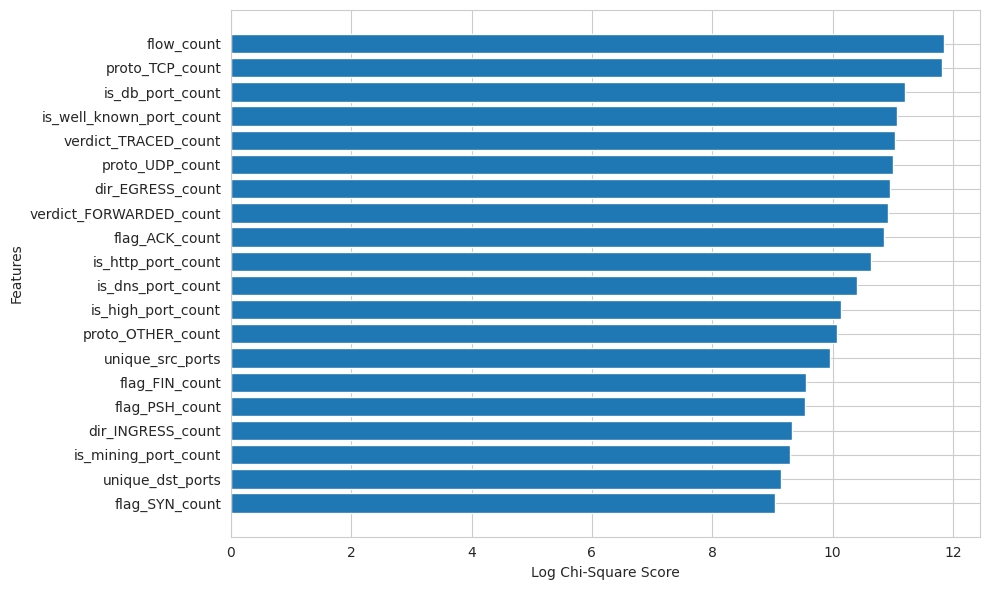

In [16]:
metadata_cols = ["session_id", "pod_name", "namespace", "label", "scenario_label", "binary_label"]
count_cols = [
    "proto_TCP", "proto_UDP", "proto_OTHER",
    "dir_EGRESS", "dir_INGRESS",
    "verdict_FORWARDED", "verdict_DROPPED", "verdict_TRACED",
    "flag_SYN", "flag_ACK", "flag_FIN", "flag_RST", "flag_PSH", "flag_URG",
    "is_well_known_port", "is_high_port", "is_dns_port", "is_http_port",
    "is_db_port", "is_mining_port",
]

if network_events.empty:
    raise ValueError("No labeled Hubble events were parsed.")

agg = (
    network_events
    .groupby(metadata_cols)
    .agg(
        flow_count=("flow_index", "count"),
        unique_src_ports=("src_port", "nunique"),
        unique_dst_ports=("dst_port", "nunique"),
        reply_ratio=("is_reply", "mean"),
        **{f"{col}_count": (col, "sum") for col in count_cols}
    )
    .reset_index()
)

for base in ["EGRESS", "INGRESS"]:
    col = f"dir_{base}_count"
    if col not in agg:
        agg[col] = 0

agg["egress_ratio"] = agg["dir_EGRESS_count"] / agg["flow_count"].clip(lower=1)
agg["ingress_ratio"] = agg["dir_INGRESS_count"] / agg["flow_count"].clip(lower=1)
agg["syn_ack_ratio"] = agg["flag_SYN_count"] / agg["flag_ACK_count"].replace(0, np.nan)
agg["syn_ack_ratio"] = agg["syn_ack_ratio"].fillna(0)

network_dataset = agg.fillna(0)

X_flow = network_dataset.drop(columns=metadata_cols)
y_flow = network_dataset["scenario_label"]

variance = X_flow.var()
non_zero_cols = variance[variance > 0].index.tolist()
X_flow = X_flow[non_zero_cols]

print(f"Network rows after per-session/pod aggregation: {len(network_dataset):,}")
print(f"Features after removing zero-variance: {len(non_zero_cols)}")
print(f"Labels: {y_flow.value_counts().sort_index().to_dict()}")
print(f"Duplicate feature rows: {X_flow.duplicated().sum():,}")

k = min(20, len(non_zero_cols))
selector = SelectKBest(chi2, k=k)
X_flow_selected = selector.fit_transform(X_flow.abs(), y_flow)

selected_features = X_flow.columns[selector.get_support()].tolist()
scores = selector.scores_[selector.get_support()]

print(f"\nSelected top {k} network features:")
for feat, score in sorted(zip(selected_features, scores), key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {score:.2f}")

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(scores)
plt.barh([selected_features[i] for i in sorted_idx], np.log1p(scores[sorted_idx]))
plt.xlabel("Log Chi-Square Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("output/network_feature_importance.png", dpi=150)
plt.show()

## 5. Split Sanity Check

In [17]:
def grouped_split_summary(df, name):
    group_col = "session_id" if df["session_id"].nunique() > 1 else "pod_name"
    y = df["scenario_label"] if "scenario_label" in df.columns else df["label"]
    groups = df[group_col]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(splitter.split(df, y, groups=groups))

    print(f"=== {name} ===")
    print(f"Group column: {group_col}")
    print(f"Train: {len(train_idx):,} | Test: {len(test_idx):,}")
    print(f"Train labels: {Counter(y.iloc[train_idx])}")
    print(f"Test labels : {Counter(y.iloc[test_idx])}")

grouped_split_summary(syscall_dataset, "Syscall Dataset")
grouped_split_summary(network_dataset, "Network Flow Dataset")

=== Syscall Dataset ===
Group column: session_id
Train: 971,711 | Test: 349,939
Train labels: Counter({7: 575057, 1: 206728, 0: 68296, 2: 60548, 3: 57492, 4: 3590})
Test labels : Counter({7: 193179, 1: 74625, 3: 35827, 2: 24894, 0: 20123, 4: 1291})
=== Network Flow Dataset ===
Group column: session_id
Train: 870 | Test: 400
Train labels: Counter({7: 339, 1: 168, 5: 111, 2: 95, 4: 51, 0: 44, 3: 37, 6: 25})
Test labels : Counter({7: 161, 1: 74, 5: 52, 2: 43, 4: 25, 0: 17, 3: 15, 6: 13})


## 6. Save Datasets

In [18]:
Path("dataset").mkdir(exist_ok=True)
Path("output").mkdir(exist_ok=True)

syscall_dataset.to_csv("dataset/syscall_dataset.csv", index=False)
print(f"Saved syscall_dataset.csv ({len(syscall_dataset):,} rows)")

flow_df_selected = network_dataset[metadata_cols].copy()
flow_df_selected[selected_features] = pd.DataFrame(
    X_flow_selected,
    columns=selected_features,
    index=network_dataset.index,
)
flow_df_selected.to_csv("dataset/network_flow_dataset.csv", index=False)
print(f"Saved network_flow_dataset.csv ({len(flow_df_selected):,} rows)")

joblib.dump(selector, "dataset/feature_selector.pkl")
joblib.dump(selected_features, "dataset/selected_features.pkl")

print("\n=== Summary ===")
print(f"Syscall: {len(syscall_dataset):,} 5-grams | Labels: {Counter(syscall_dataset['scenario_label'])}")
print(f"Network: {len(flow_df_selected):,} pod/session rows | Labels: {Counter(flow_df_selected['scenario_label'])}")
print(f"Selected network features: {selected_features}")

Saved syscall_dataset.csv (1,321,650 rows)
Saved network_flow_dataset.csv (1,270 rows)

=== Summary ===
Syscall: 1,321,650 5-grams | Labels: Counter({7: 768236, 1: 281353, 3: 93319, 0: 88419, 2: 85442, 4: 4881})
Network: 1,270 pod/session rows | Labels: Counter({7: 500, 1: 242, 5: 163, 2: 138, 4: 76, 0: 61, 3: 52, 6: 38})
Selected network features: ['flow_count', 'unique_src_ports', 'unique_dst_ports', 'proto_TCP_count', 'proto_UDP_count', 'proto_OTHER_count', 'dir_EGRESS_count', 'dir_INGRESS_count', 'verdict_FORWARDED_count', 'verdict_TRACED_count', 'flag_SYN_count', 'flag_ACK_count', 'flag_FIN_count', 'flag_PSH_count', 'is_well_known_port_count', 'is_high_port_count', 'is_dns_port_count', 'is_http_port_count', 'is_db_port_count', 'is_mining_port_count']


## 7. Visualization

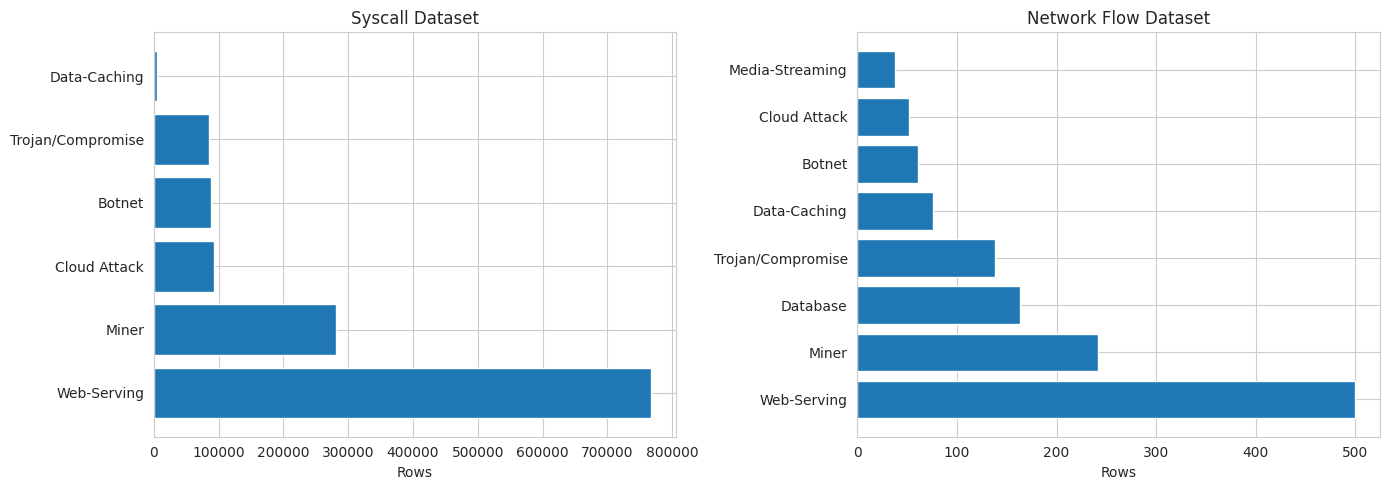

Preprocessing complete.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

syscall_counts = syscall_dataset["scenario_label"].map(LABEL_NAMES).value_counts()
axes[0].barh(syscall_counts.index, syscall_counts.values)
axes[0].set_title("Syscall Dataset")
axes[0].set_xlabel("Rows")

flow_counts = flow_df_selected["scenario_label"].map(LABEL_NAMES).value_counts()
axes[1].barh(flow_counts.index, flow_counts.values)
axes[1].set_title("Network Flow Dataset")
axes[1].set_xlabel("Rows")

plt.tight_layout()
plt.savefig("output/label_distribution.png", dpi=150)
plt.show()

print("Preprocessing complete.")